In [55]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
# from sklearn

In [5]:
df = pd.read_csv('../data/complete_dataset.csv')

In [11]:
display(df)

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2020-10-02,99585.835,-6.076028,41988.240,26.980251,57597.595,-30.173823,0.625000,12.8,26.0,22.0,0.0,N,N
2102,2020-10-03,92277.025,-1.983471,44133.510,32.438156,48143.515,-33.538025,0.583333,17.4,29.4,19.8,0.0,N,N
2103,2020-10-04,94081.565,25.008614,88580.995,26.571687,5500.570,-0.163066,0.062500,13.5,29.5,8.4,0.0,N,N
2104,2020-10-05,113610.030,36.764701,106587.375,39.616015,7022.655,-6.511550,0.083333,9.1,12.7,7.3,12.8,N,N


In [14]:
df.columns

Index(['date', 'demand', 'RRP', 'demand_pos_RRP', 'RRP_positive',
       'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP', 'min_temperature',
       'max_temperature', 'solar_exposure', 'rainfall', 'school_day',
       'holiday'],
      dtype='object')

In [22]:
df.dtypes

date                object
demand             float64
RRP                float64
demand_pos_RRP     float64
RRP_positive       float64
demand_neg_RRP     float64
RRP_negative       float64
frac_at_neg_RRP    float64
min_temperature    float64
max_temperature    float64
solar_exposure     float64
rainfall           float64
school_day          object
holiday             object
dtype: object

In [23]:
df.isna().sum()

date               0
demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     1
rainfall           3
school_day         0
holiday            0
dtype: int64

In [28]:
df.duplicated().sum()

0

In [33]:
print('---MIN---')
print()
print(df.min())

---MIN---

date               2015-01-01
demand              85094.375
RRP                 -6.076028
demand_pos_RRP       41988.24
RRP_positive        13.568986
demand_neg_RRP            0.0
RRP_negative          -342.22
frac_at_neg_RRP           0.0
min_temperature           0.6
max_temperature           9.0
solar_exposure            0.7
rainfall                  0.0
school_day                  N
holiday                     N
dtype: object


In [31]:
print('---MAX---')
print()
print(df.max())

---MAX---

date                2020-10-06
demand               170653.84
RRP                4549.645105
demand_pos_RRP       170653.84
RRP_positive       4549.645105
demand_neg_RRP       57597.595
RRP_negative               0.0
frac_at_neg_RRP          0.625
min_temperature           28.0
max_temperature           43.5
solar_exposure            33.3
rainfall                  54.6
school_day                   Y
holiday                      Y
dtype: object


In [34]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [35]:
df.dtypes

date               datetime64[ns]
demand                    float64
RRP                       float64
demand_pos_RRP            float64
RRP_positive              float64
demand_neg_RRP            float64
RRP_negative              float64
frac_at_neg_RRP           float64
min_temperature           float64
max_temperature           float64
solar_exposure            float64
rainfall                  float64
school_day                 object
holiday                    object
dtype: object

In [36]:
df['date']

0      2015-01-01
1      2015-01-02
2      2015-01-03
3      2015-01-04
4      2015-01-05
          ...    
2101   2020-10-02
2102   2020-10-03
2103   2020-10-04
2104   2020-10-05
2105   2020-10-06
Name: date, Length: 2106, dtype: datetime64[ns]

In [39]:
df = df.fillna(df.median(numeric_only=True))

In [40]:
df.isna().sum()

date               0
demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     0
rainfall           0
school_day         0
holiday            0
dtype: int64

In [41]:
df[['school_day', 'holiday']] = df[['school_day', 'holiday']].replace({'Y': 1, 'N': 0})

C:\Users\avina\AppData\Local\Temp\ipykernel_37948\2548764648.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['school_day', 'holiday']] = df[['school_day', 'holiday']].replace({'Y': 1, 'N': 0})


In [42]:
df.dtypes

date               datetime64[ns]
demand                    float64
RRP                       float64
demand_pos_RRP            float64
RRP_positive              float64
demand_neg_RRP            float64
RRP_negative              float64
frac_at_neg_RRP           float64
min_temperature           float64
max_temperature           float64
solar_exposure            float64
rainfall                  float64
school_day                  int64
holiday                     int64
dtype: object

In [43]:
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['date'].dt.dayofweek.isin([5,6]).astype(int)

In [45]:
df.dtypes

date               datetime64[ns]
demand                    float64
RRP                       float64
demand_pos_RRP            float64
RRP_positive              float64
demand_neg_RRP            float64
RRP_negative              float64
frac_at_neg_RRP           float64
min_temperature           float64
max_temperature           float64
solar_exposure            float64
rainfall                  float64
school_day                  int64
holiday                     int64
month                       int32
day_of_week                 int32
is_weekend                  int32
dtype: object

In [ ]:
df = df.drop(columns = ['RRP', 'demand_pos_RRP', 'RRP_positive', 'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP'])

KeyError: "['RRP', 'demand_pos_RRP', 'RRP_positive', 'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP'] not found in axis"

In [51]:
df.dtypes

date               datetime64[ns]
demand                    float64
min_temperature           float64
max_temperature           float64
solar_exposure            float64
rainfall                  float64
school_day                  int64
holiday                     int64
month                       int32
day_of_week                 int32
is_weekend                  int32
dtype: object

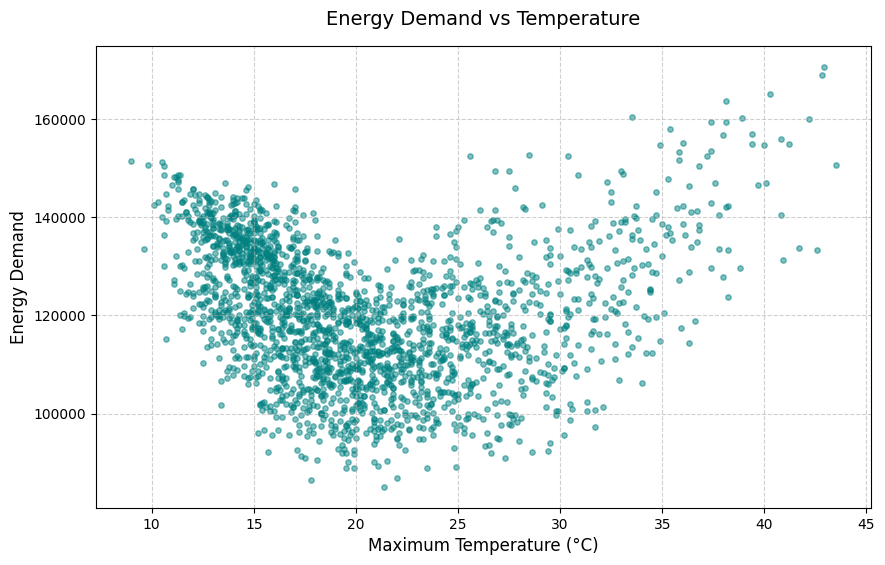

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(df['max_temperature'], df['demand'], color = 'teal', alpha=0.5, s=15)

plt.title('Energy Demand vs Temperature', fontsize=14, pad=15)
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Energy Demand', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('../img/Energy Demand vs Temperature', dpi=300, bbox_inches='tight')

plt.show()

In [60]:
df.to_csv('../data/cleaned_energy_demand.csv', index=False)